
Script générant un attaque adverse simple : rotation. On teste :

- Tous les zooms entre x0.1 et x10 pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction du zoom
- Tous les zomms  entre x0.1 et x10 pour chaque image pour un label donné pour obtenir les zooms maximisant ou minimisant la prediction d'un réseau sur ce label


> ... TODO ... # Adapt the script to zoom transfromation and test networks


In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


# testing each network for different rotations

In [2]:
args = Params()
args.size_ratio = 0.1
all_ratios = np.arange(args.size_ratio, (10 + args.size_ratio), 0.1).round(1)
im_zero = int((1 - all_ratios[0] ) * 10 )
#for data_set_type in data_set_types:
for data_set_type in ['full', 'bbox']:
    
    print(50*'=')
    print(f'{data_set_type=}')

    args.do_zoom = True
    #args.do_rot_train = True
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')
        
    for model_name in  ['resnet18', 'resnet50', 'resnet101'] : #, 
        print(f'{model_name=}')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            attack_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations_test.parquet'
            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations_acc.parquet'
            if os.path.isfile(df_filename_acc):
                df_angle = pd.read_parquet(df_filename_acc)
            else:
                df_mean, df_attack = None, None
                print(f'Computing {df_filename_acc}')

                image_dataset = image_datasets_transforms(args)

                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

                if os.path.isfile(model_filename):
                    print(f"Loading pre-trained resnet {model_filename}")
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                
                    pprint(f'Testing : {model_name}')

                    torch.cuda.amp.GradScaler(enabled=True)
                    model = model.eval()
                    
                    with torch.no_grad():
                        acc_zoom =  torch.zeros(len(all_ratios))
                        for i_image, (data, label) in tqdm(enumerate(image_dataset)) : 
                            label_batch = (torch.ones([len(data)])*label).data
                            
                            data = data.to(device)
                    
                            outputs = model(data)
                    
                            outputs = torch.softmax(outputs, dim=1)
                    
                            prior_outputs = outputs[:,label]
                            argmax = torch.argmax(prior_outputs)
                            argmin = torch.argmin(prior_outputs)
                    
                    
                            _, preds = torch.max(outputs.data.cpu(), dim=1)
                    
                            acc_zoom += ((preds.float() == label_batch)*1.).cpu()

                            
                            df_attack_ = pd.DataFrame({'likelihood_0':[prior_outputs[im_zero].item()], '0_pred':torch.argmax(outputs[im_zero]).item(), 
                                                'likelihood_max':prior_outputs[argmax].item(), 'max_pos':all_ratios[argmax.item()], 'max_pred':torch.argmax(outputs[argmax]).item(), 
                                                'likelihood_min':prior_outputs[argmin].item(), 'min_pos':all_ratios[argmin.item()], 'min_pred':torch.argmax(outputs[argmin]).item(), 
                                                'i_image':i_image, 'filename':image_dataset.imgs[i_image][0], 'label':label})
                            
                            df_attack = store_pandas(df_attack, df_attack_)
                    
                        acc_zoom /= len(image_dataset)
                        df_mean_ = pd.DataFrame({'mean_accuracy':[acc_zoom], 'var':[all_ratios]})
                        df_mean = store_pandas(df_mean, df_mean_)
                        model.cpu()
                        df_mean.to_parquet(df_filename_acc)
                        df_attack.to_parquet(attack_filename)

data_set_type='full'
--------------------------------------------------
model_name='resnet18'
args.do_polar=False
..................................................
Computing cached_data/2024-05-24_full_resnet18_cartesian_results_test-rotations_acc.parquet
Loaded 50000 images under val
Loading pre-trained resnet cached_data/2024-05-24_full_resnet18_cartesian.pt
loading .... cached_data/2024-05-24_full_resnet18_cartesian.pt
------------------
Testing : resnet18
------------------


146it [00:31,  4.68it/s]

KeyboardInterrupt



[-180, -173, -166, -158, -151, -144, -136, -129, -122, -114, -107, -100, -92, -85, -78, -70, -63, -56, -48, -41, -34, -26, -19, -12, -4, 11, 18, 25, 33, 40, 47, 55, 62, 69, 77, 84, 91, 99, 106, 113, 121, 128, 135, 143, 150, 157, 165, 172, 180]
model_name='resnet18'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


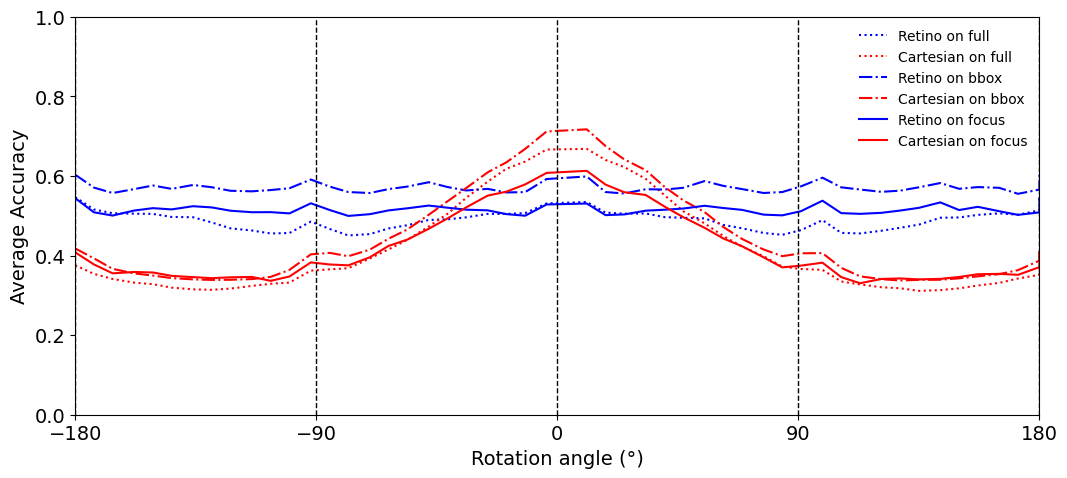

model_name='resnet50'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


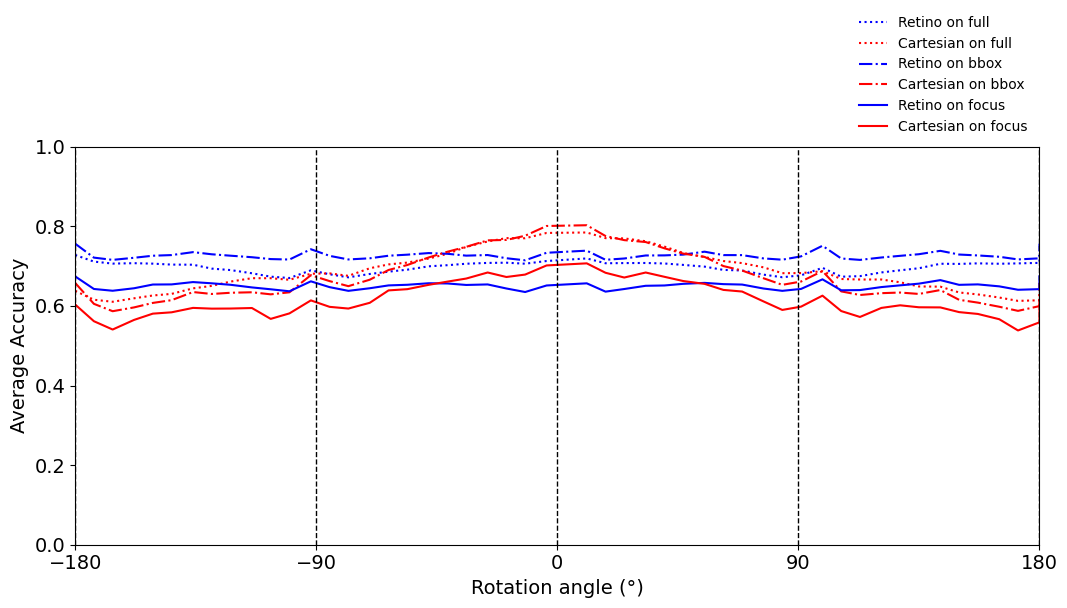

model_name='resnet101'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


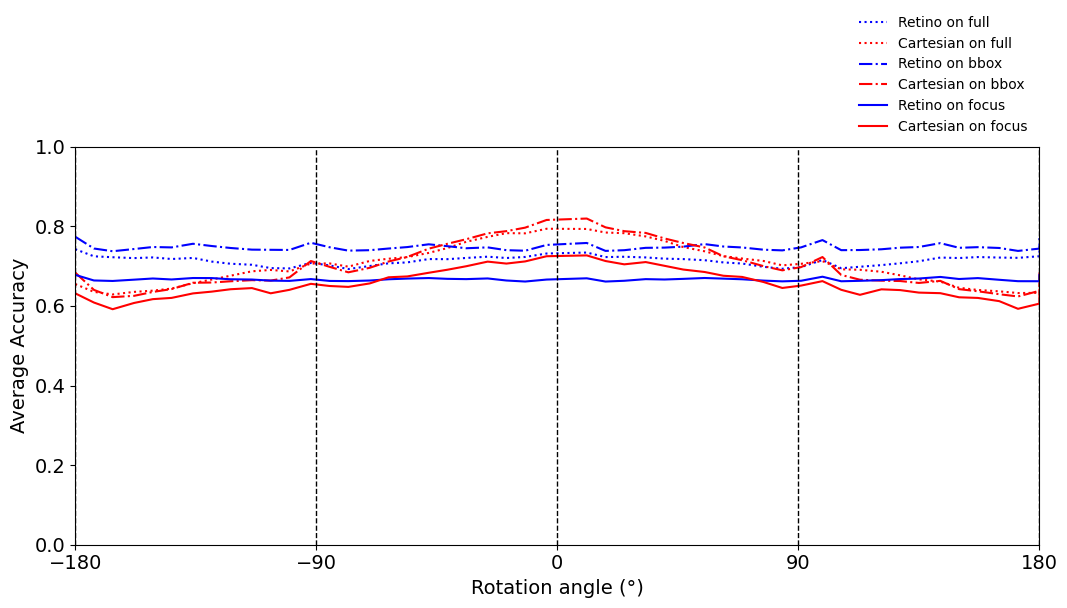

In [5]:

for model_name in  ['resnet18', 'resnet50', 'resnet101', ]:
    print(50*'=')
    print(f'{model_name=}')
    fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
    for data_set_type, ls in zip(data_set_types, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-zoom_acc.parquet'
            

            if os.path.isfile(df_filename):
                df_zoom = pd.read_parquet(df_filename)

                results = []
                for i in df_zoom['mean_accuracy'][0].split(' '):
                    if len(i) > 1:
                        results.append(float(i.replace('\n', '').replace('[', '').replace(']', '')))
                        
                label = 'Retino' if do_polar else 'Cartesian'
                label += f' on {data_set_type}'
                ax.plot(np.hstack((zoom_df, 2)), results, color=color, ls=ls, label=label)
        
    #ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlim(-180, 180)
    ax.set_ylim(0, 1)

    for zoom in all_ratios:
        ax.axvline(x=zoom, c='k', ls='--', lw=1)
    ax.set_xticks(all_ratios)
    #ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
    #ax.set_yticks([.7, .75, .8])
    ax.set_ylabel('Average Accuracy', font=font)
    ax.set_xlabel('Zoom ratio', font=font)
    plt.legend(bbox_to_anchor=(0.8, 1), loc='best', fontsize=10, edgecolor='none')
    plt.tight_layout()
    # plt.xticks(font=font)
    # plt.yticks(font=font);
    plt.show()

# analysis: average accuracy for different rotations

In [5]:
#Rotation attack read out
acc_plot = {}
for model_name in  ['resnet18', 'resnet50', 'resnet101', ]:
    print(50*'=')
    print(f'{model_name=}')
    for data_set_type, ls in zip(data_set_type, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-zoom.parquet'
            

            if os.path.isfile(df_filename_acc):

                    df_zoom = pd.read_parquet(df_filename_acc)
                    print(do_polar)
                    min = accuracy_score(df_zoom['min_pred'], df_zoom["label"])
                    print(min, 'min')
                    zero = accuracy_score(df_zoom['0_pred'], df_zoom["label"])
                    print(zero, 'zero')
                    max = accuracy_score(df_zoom['max_pred'], df_zoom["label"])
                    print(max, 'max')
                    print(zero-min, 'delta1', max-zero, 'delta2')

                    acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_min'] = min

                    results = []
                    for i in df_zoom['mean_accuracy'][0].split(' '):
                        if len(i) > 1:
                            results.append(float(i.replace('\n', '').replace('[', '').replace(']', '')))

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_zero'] = results[len(results)//2]

model_name='resnet101'
data_set_type='full'
--------------------------------------------------
True
0.49652 min
0.74262 zero
0.8725 max
0.24609999999999993 delta1 0.1298800000000001 delta2
False
0.4202 min
0.65496 zero
0.89828 max
0.23475999999999997 delta1 0.24331999999999998 delta2
data_set_type='bbox'
--------------------------------------------------
True
0.57722 min
0.774 zero
0.87348 max
0.19678000000000007 delta1 0.09948000000000001 delta2
False
0.40108 min
0.6839 zero
0.91466 max
0.28281999999999996 delta1 0.23076000000000008 delta2


In [6]:
fig_width = 15
fontsize = 21
font = font_manager.FontProperties(weight='normal', size=fontsize)
dpi = 'figure'
dpi = 200
opts_savefig = dict(dpi=dpi, bbox_inches='tight', pad_inches=0, edgecolor=None)

colors = ['b', 'r', 'k', 'g', 'm', 'y']
fig_width = 20
phi = (np.sqrt(5)+1)/2 # golden ratio for the figures :-)

data_set_type='full'
model_name='resnet101'
--------------------------------------------------
data_set_type='bbox'
model_name='resnet101'
--------------------------------------------------


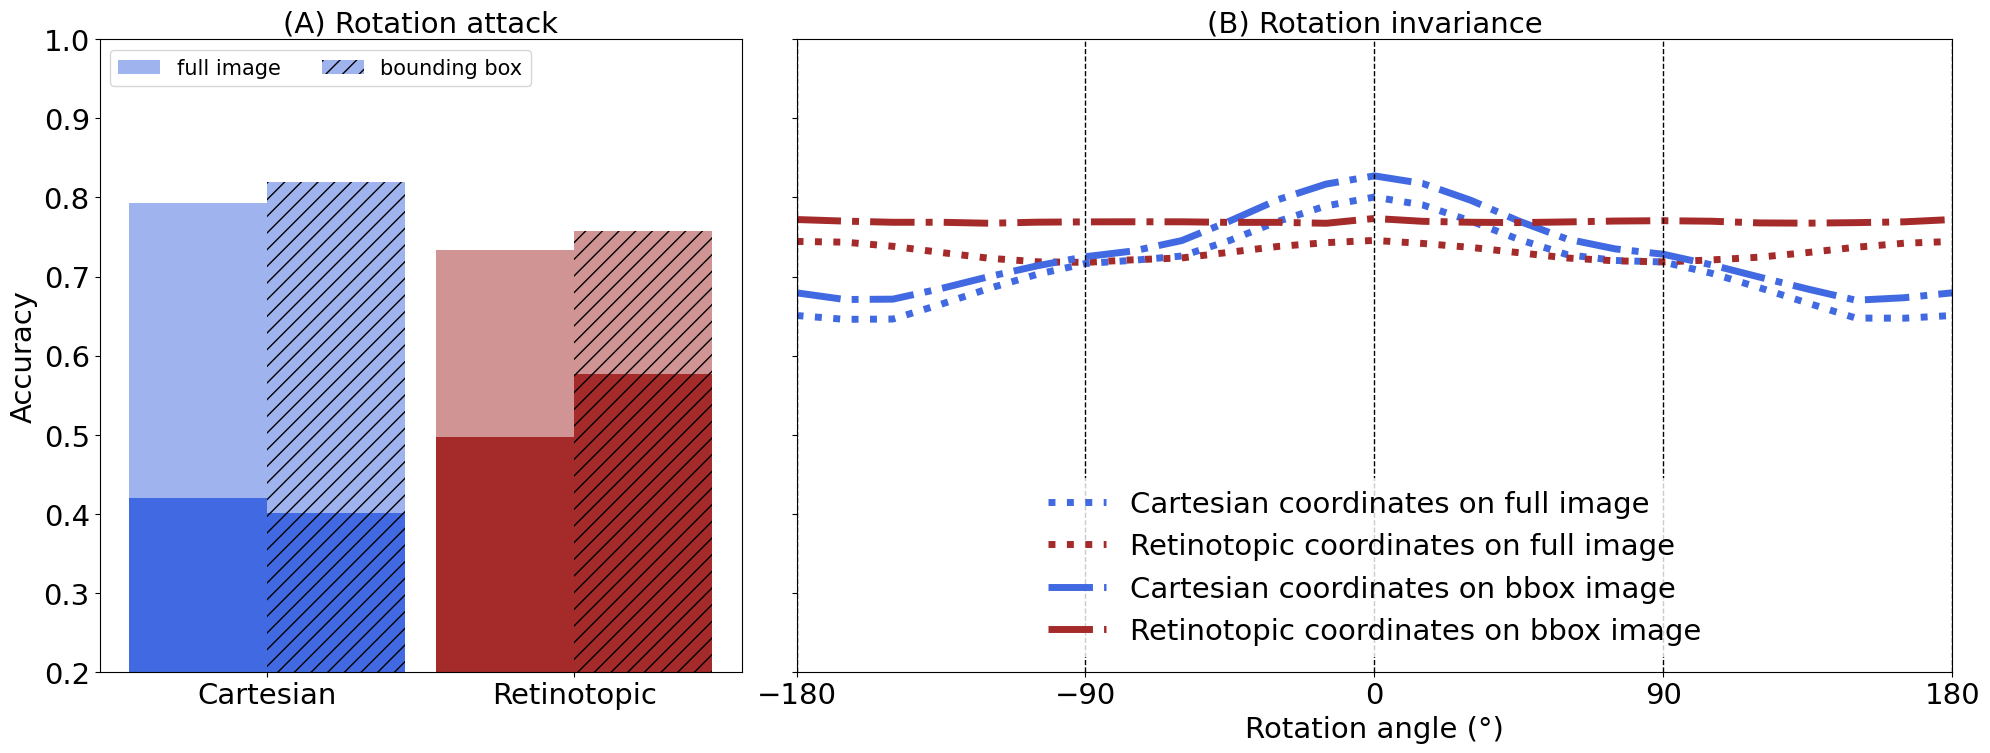

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
fig, axs = plt.subplots(1, 2, sharex=False, sharey=True, figsize=(fig_width, fig_width/2.61803), width_ratios=[1, 1.8])

titles = ["(A) Zoom attack", "(B) Zoom invariance"]

#colors_cart = ['lightsteelblue', 'brown']
colors = ['royalblue', 'brown']
acc_full_ret_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_min']

acc_full_ret = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_zero']

acc_full_lin_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_min']

acc_full_lin = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_zero']

acc_bbox_ret_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_min']

acc_bbox_ret = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_zero']

acc_bbox_lin_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_min']

acc_bbox_lin = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_zero']


type_mod = ("Cartesian", "Retinotopic")
data_means = {
    'full image': (acc_full_lin, acc_full_ret),
    'bounding box': (acc_bbox_lin, acc_bbox_ret ),

}

x = np.arange(len(type_mod))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0
hatchs = [None, "//"]

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, label=attribute, alpha =.5, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

data_means = {
    'full image': (acc_full_lin_min, acc_full_ret_min),
    'bounding box': (acc_bbox_lin_min, acc_bbox_ret_min )
}
multiplier = 0

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

axs[0].set_xticks(x + width/2, type_mod)
axs[0].set_ylabel('Accuracy', font=font)
axs[0].legend(loc='upper left', ncols=2, fontsize=15)
axs[0].set_ylim(0.2, 1)


for data_set_type, ls in zip(['full', 'bbox'], data_set_linestyles):
    print(f'{data_set_type=}')
    for model_name in  ['resnet101']:
        print(50*'=')
        print(f'{model_name=}')

        print(50*'-')

        for do_polar, color in zip([False, True],  ['royalblue', 'brown']):

            df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations.json'

            if os.path.isfile(df_filename):
               # data_set_type = 'full image' if 'full' in data_set_type else 'bounding box'
                
                df_zoom = pd.read_json(df_filename)

                results = [df_zoom[df_zoom['zoom'] == zoom]['match'].mean() for zoom in np.hstack((df_zoom['zoom'].unique(), -180.))]
                label = 'Retinotopic coordinates' if do_polar else 'Cartesian coordinates'
                label += f' on {data_set_type} image' 
                axs[1].plot(np.hstack((df_zoom['zoom'].unique(), 180)), results, color=color, ls=ls, lw=5, label=label)
        

ax = axs[1]
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlim(-180, 180)


for zoom in all_ratios:
    ax.axvline(x=zoom, c='k', ls='--', lw=1)
ax.set_xticks(all_ratios)
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
#ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Zoom ratio (°)', font=font)
plt.legend(loc='lower center', fontsize=fontsize, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
for j, ax in enumerate(axs):
        ax.set_title(titles[j], font=font)
        ax.tick_params(axis='both', labelsize=fontsize)    
        #for i, container in enumerate(ax.containers):
        #    ax.bar_label(container, padding=-15, color='black', fmt='%.3f', rotation=0, label_type = 'edge', fontsize=fontsize, weight='bold')

plt.xticks(font=font)
plt.yticks(font=font)
plt.tight_layout()

In [8]:
for ext in ['pdf', 'png']:
    fig.savefig(f'figs/fig-zoom_FENS.{ext}',  **opts_savefig)